# TEMPO Performance Benchmark: Serial Method Comparison
## Demonstrating Speedup via Optimized Hamiltonian Evaluation

This notebook demonstrates the primary performance advantage of TEMPO: 
efficient handling of time-dependent pulse sequences with many pulses.

**Key Questions This Addresses:**
- How does TEMPO's `serial_safe` method compare to standard QuTiP `mesolve`?
- When does the performance advantage emerge? (What regime requires many pulses?)
- How does speedup scale with sequence complexity?

**System:** NV center spin system under resonant AC driving field  
**Methods Compared:**
- `mesolve` (baseline): QuTiP's standard Lindblad master equation solver
- `serial_safe` (TEMPO): TEMPO's optimized method for pulse sequences

In [35]:
import sys
import os
import time
import random
import math
from tqdm.notebook import tqdm

import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import seaborn as sns

from qutip import basis, sigmax, sigmay, sigmaz, qeye

# Import TEMPO package components
from tempo.hamiltonian import Hamiltonian
from tempo.pulse_recipe import Pulse_recipe
from tempo.pulse import Pulse
from tempo.evolver import Evolver
from tempo.pulse_sequence import Pulse_sequence

%matplotlib inline

print("All packages imported successfully")

All packages imported successfully


In [3]:
# ============================================================
# PUBLICATION-QUALITY PLOTTING CONFIGURATION
# ============================================================

# Unit conversion
cm = 1/2.54  # centimeters to inches

# Set global matplotlib parameters for publication-quality figures
matplotlib.rc('font', family='Helvetica')

font1 = {'fontname': 'Helvetica', 'weight': 'normal', 'fontsize': 9}
font = font_manager.FontProperties(
    family='Helvetica',
    weight='normal', 
    style='normal',
    size=9
)

# Line and axis styling
linewidth_plt = 2
axeswidth = 0.6
majortickfontsize = 7

plt.rcParams['lines.linewidth'] = linewidth_plt
plt.rcParams['axes.linewidth'] = axeswidth
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = majortickfontsize
plt.rcParams['ytick.labelsize'] = majortickfontsize
plt.rcParams['axes.labelpad'] = 3

# Tick configuration
majortickwidth = axeswidth
minortickwidth = axeswidth
majorticklength = 3
minorticklength = 1.2

plt.rcParams['xtick.major.width'] = majortickwidth
plt.rcParams['xtick.major.size'] = majorticklength
plt.rcParams['ytick.major.width'] = majortickwidth
plt.rcParams['ytick.major.size'] = majorticklength
plt.rcParams['xtick.minor.width'] = minortickwidth
plt.rcParams['xtick.minor.size'] = minorticklength
plt.rcParams['ytick.minor.width'] = minortickwidth
plt.rcParams['ytick.minor.size'] = minorticklength

# Axis appearance
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True

# Math text
plt.rcParams['mathtext.fontset'] = 'cm'

print("Plotting style configured for publication output")

Plotting style configured for publication output


## System Definition
### NV Center Spin in Static Magnetic Field

**Physical System:**
- 2-level NV center spin system (m_s = 0 and m_s = +1 states)
- Static magnetic field (Zeeman splitting)
- Time-dependent AC drive pulses (resonant X-axis oscillations)

**This Example Is:**
- A realistic quantum control scenario
- Clear/known physics: Rabi oscillations between spin states
- Demonstrates bottleneck: Many pulses leads to many Hamiltonian evaluations

In [5]:
# ============================================================
# APPLY STATIC MAGNETIC FIELD
# ============================================================

# Magnetic field components (in Gauss)
Bx = 100
By = 0
Bz = 300

B0_init = np.array([Bx, By, Bz])
print(f"Magnetic field: B = ({Bx}, {By}, {Bz}) G")
print(f"  Magnitude: {np.linalg.norm(B0_init):.1f} G")

# Option: rotate magnetic field around y-axis (set theta=0 to skip)
theta = 0  # degrees
theta_rad = theta * np.pi / 180

Ry = np.array([
    [np.cos(theta_rad), 0, np.sin(theta_rad)],
    [0, 1, 0],
    [-np.sin(theta_rad), 0, np.cos(theta_rad)]
])

B0 = np.dot(Ry, B0_init)
print(f"After rotation by {theta}°: B = {B0}")

Magnetic field: B = (100, 0, 300) G
  Magnitude: 316.2 G
After rotation by 0°: B = [100.   0. 300.]


In [6]:
# ============================================================
# STATIC HAMILTONIAN: ZEEMAN SPLITTING
# ============================================================

def zeeman_function(ops, pars):
    """
    Zeeman Hamiltonian for NV center: H = -γ_NV * (B · S)
    
    Parameters:
    -----------
    ops : dict
        Dictionary with 'S1' = (S_x, S_y, S_z) spin operators
    pars : dict
        Dictionary with 'coeff', 'gammaNV' (gyromagnetic ratio), 'Bfield'
    
    Returns:
    --------
    float
        Energy value for given B field configuration
    """
    # Unpack spin operators (Pauli matrices)
    Sx, Sy, Sz = ops['S1']
    
    # Compute B · S = Bx*Sx + By*Sy + Bz*Sz
    B_dot_S = (
        pars['Bfield'][0] * Sx +
        pars['Bfield'][1] * Sy +
        pars['Bfield'][2] * Sz
    )
    
    # Hamiltonian: H = coeff * γ_NV * (B · S)
    return pars['coeff'] * pars['gammaNV'] * B_dot_S


# Hamiltonian parameters
zeeman_params = {
    'coeff': -2 * np.pi,           # Converts MHz to rad/ns
    'Bfield': B0,                  # Magnetic field vector (G)
    'gammaNV': -2.8025             # NV gyromagnetic ratio (MHz/G)
}

# Operator matrices
zeeman_ops = {
    'S1': (sigmax(), sigmay(), sigmaz())  # Pauli matrices
}

# Create Hamiltonian object
H_zeeman = Hamiltonian(zeeman_ops, zeeman_params, zeeman_function)

# Extract static Hamiltonian operator
Hstat = H_zeeman.H

print("Static Zeeman Hamiltonian created:")
print(Hstat)

Static Zeeman Hamiltonian created:
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 5282.58804701  1760.86268234]
 [ 1760.86268234 -5282.58804701]]


In [7]:
# ============================================================
# CALCULATE TRANSITION FREQUENCY
# ============================================================

# Get eigenvalues of static Hamiltonian
eig_energies = Hstat.eigenenergies() / (2 * np.pi)  # Convert to MHz

print(f"Hamiltonian eigenvalues:")
print(f"  E_0 = {eig_energies[0]:.2f} MHz")
print(f"  E_1 = {eig_energies[1]:.2f} MHz")

# Transition frequency (|0⟩ → |1⟩)
frq_trans = eig_energies[1] - eig_energies[0]
print(f"\nTransition frequency (|0⟩ ↔ |1⟩): {frq_trans:.2f} MHz")

Hamiltonian eigenvalues:
  E_0 = -886.23 MHz
  E_1 = 886.23 MHz

Transition frequency (|0⟩ ↔ |1⟩): 1772.46 MHz


In [8]:
# ============================================================
# INITIAL QUANTUM STATE
# ============================================================

# Initialize in ground state |0⟩ (m_s = 0)
state_init = basis(2, 0)

print("Initial state: |0⟩ (m_s = 0)")
print(state_init)

Initial state: |0⟩ (m_s = 0)
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]


## Pulse Definition
### Time-Dependent AC Drive

We apply resonant X-axis oscillations to induce Rabi oscillations:

$$H_{\text{drive}}(t) = B_{\text{amp}} \cos(2\pi f_{\text{trans}} \cdot t) \cdot \sigma_x$$

where:
- $f_{\text{trans}}$ = transition frequency
- $B_{\text{amp}}$ = drive field amplitude (in Gauss)
- $\sigma_x$ = Pauli X operator

In [10]:
# ============================================================
# AC DRIVE PULSE CONFIGURATION
# ============================================================

# Specify drive field strength
gammaNV = -2.8025  # NV gyromagnetic ratio (MHz/G)
BacMHz = 30        # Drive frequency in MHz (Rabi frequency)

# Convert frequency to field amplitude
B_amp = BacMHz / gammaNV

print(f"AC Drive configuration:")
print(f"  Rabi frequency: {BacMHz} MHz")
print(f"  Required B-field amplitude: {abs(B_amp):.2f} G")


# Define time-dependent pulse function
def ACD_pulse(t, args):
    """
    AC Drive pulse: amplitude * cos(2π * frequency * t)
    
    Parameters:
    -----------
    t : float
        Time (in microseconds)
    args : dict
        Contains 'B_amp' (amplitude) and 'freq' (resonance frequency)
    
    Returns:
    --------
    float
        Pulse amplitude at time t
    """
    return args['B_amp'] * np.cos(2 * np.pi * args['freq'] * t)


# Hamiltonian operator for AC drive (σ_x coupling)
H_drive = 2 * np.pi * gammaNV * sigmax()

# Parameter names that will be passed to ACD_pulse
drive_param_names = ['B_amp', 'freq']

# Create pulse recipe (blueprint for any AC drive pulse)
# Numerical parameters will be specified per-pulse
ACDpulsetype = Pulse_recipe(
    Hamiltonian(H_drive),
    drive_param_names,
    ACD_pulse
)

print(f"AC Drive pulse recipe created")
print(f"  Pulse parameters: {drive_param_names}")

AC Drive configuration:
  Rabi frequency: 30 MHz
  Required B-field amplitude: 10.70 G
AC Drive pulse recipe created
  Pulse parameters: ['B_amp', 'freq']


## Performance Benchmark: Testing the Bottleneck

### The Hamiltonian Evaluation Bottleneck

**Why TEMPO Provides Speedup:**

In standard QuTiP workflows (mesolve), when you have many time-dependent pulses, 
the Hamiltonian must be **re-evaluated at every time step** for each pulse.

**Computational Cost Example (pseudo-code):**

`for each time step t:`

`for each pulse in sequence:`

`H(t) = H_static + coefficient(t) * H_pulse`

With many pulses, this becomes expensive. **TEMPO's serial method** pre-computes 
and reorganizes the Hamiltonian coefficients to avoid redundant evaluation.

### Test Design

We measure wall-clock time for increasing complexity:
- **Vary number of pulses**: 2, 3, 4, 5, 10, 20, 30, 40, 50
- **Vary sequence duration**: 0.5 - 3.0 μs
- **Multiple repetitions**: Average over 5 runs per configuration
- **Methods compared**: `mesolve` (regular) vs `serial_safe` (TEMPO)

## What Should Happen
The baseline `mesolve` method exhibits approximately linear scaling of simulation time with pulse count. Each added pulse requires additional Hamiltonian coefficient evaluations at every integration step. TEMPO's serial method should show substantially flattened scaling with pulse count because it is pre-computing Hamiltonian coefficients. We therefore expect the performance gap to widen dramatically as we increase pulse counts, where the advantage becomes increasingly pronounced.

In [15]:
# ============================================================
# DEFINE SWEEP PARAMETERS FOR TIMING TESTS
# ============================================================

# Number of pulses to test
num_pulses = np.array([2, 3, 4, 5, 10, 20, 30, 40, 50])

# Base sequence duration (in microseconds)
seq_duration = 0.5

# Multipliers for sequence duration to create different total durations
# This gives total durations from 0.5 to 3.0 microseconds
seq_len_multipliers = np.linspace(1, 6, 15)

# Number of repetitions per configuration (for averaging)
nrepeat = 1

print(f"Sweep parameter configuration:")
print(f"  Number of pulses: {num_pulses}")
print(f"  Base sequence duration: {seq_duration} μs")
print(f"  Duration multipliers: {len(seq_len_multipliers)} values from {seq_len_multipliers.min():.2f}x to {seq_len_multipliers.max():.2f}x")
print(f"  Repetitions per config: {nrepeat}")

# Total configurations to test
n_configs = len(num_pulses) * len(seq_len_multipliers) * nrepeat
print(f"\nTotal configurations: {n_configs}")
print(f"  ({len(num_pulses)} pulses × {len(seq_len_multipliers)} durations × {nrepeat} reps)")

Sweep parameter configuration:
  Number of pulses: [ 2  3  4  5 10 20 30 40 50]
  Base sequence duration: 0.5 μs
  Duration multipliers: 15 values from 1.00x to 6.00x
  Repetitions per config: 1

Total configurations: 135
  (9 pulses × 15 durations × 1 reps)


In [16]:
# ============================================================
# CREATE SWEEP PARAMETER LIST
# ============================================================

# Create list of all parameter combinations
sweep_parameters = []

for n in num_pulses:
    for j in seq_len_multipliers:
        for i_rep in range(nrepeat):
            sweep_parameters.append([n, j, i_rep])

# Randomize order to avoid bias from sequential execution
# (helps account for CPU temperature/throttling effects)
random.shuffle(sweep_parameters)

print(f"Created {len(sweep_parameters)} parameter combinations")
print(f"Order randomized to reduce systematic timing bias")

Created 135 parameter combinations
Order randomized to reduce systematic timing bias


In [17]:
# ============================================================
# MAIN TIMING LOOP: MEASURE EXECUTION TIME
# ============================================================

# Define solver options
# These are strict tolerances to ensure accurate quantum evolution
opts = {
    'nsteps': 1_000_000,  # Max internal steps (increased for complex sequences)
    'atol': 1e-6,         # Absolute tolerance
    'rtol': 1e-6          # Relative tolerance
}

print("Starting timing benchmarks...")
print(f"Solver tolerances: atol={opts['atol']}, rtol={opts['rtol']}")
print(f"Maximum internal steps: {opts['nsteps']:,}")
print("-" * 60)

# Record start time for full benchmark
sequence_start = time.time()

# Storage for timing results
reg_times = []           # Wall-clock times for 'regular' method
serial_safe_times = []   # Wall-clock times for 'serial_safe' method

# ============================================================
# Loop through all parameter combinations
# ============================================================

for par in tqdm(sweep_parameters, desc="Running timing tests"):
    n, j, i_rep = par
    
    # ========== CREATE PULSE SEQUENCE ==========
    ps = Pulse_sequence(Hstat=Hstat)
    
    # Calculate total sequence duration
    t_max = seq_duration * j  # microseconds
    
    # Time points at which to evaluate the state
    # (100 points spanning full sequence duration)
    arr_times = np.linspace(0, t_max, 100)
    
    # Duration of each individual pulse
    dt = t_max / n
    
    # Add pulses to sequence, evenly spaced throughout duration
    for i in range(n):
        starttime = i * dt
        
        # Handle rounding: last pulse ends exactly at t_max
        if i == n - 1:
            duration = t_max - starttime
        else:
            duration = dt
        
        # Create pulse with AC drive parameters
        pulse = Pulse(
            ACDpulsetype,
            start_time=starttime,
            duration=duration,
            coeff_params={
                'B_amp': B_amp,           # Drive field amplitude
                'freq': frq_trans         # Resonance frequency
            }
        )
        ps.add_pulse(pulse)
    
    # ========== CREATE EVOLVER ==========
    ev = Evolver(state_init, arr_times, ps, opts=opts)
    
    # ========== TIME REGULAR METHOD ==========
    # Standard QuTiP mesolve: re-evaluates Hamiltonian at each time step
    start_regular = time.time()
    result_regular = ev.evolve(method='regular')
    end_regular = time.time()
    time_regular = end_regular - start_regular
    
    # ========== TIME SERIAL_SAFE METHOD ==========
    # TEMPO's optimized method: pre-computed Hamiltonian coefficients
    start_serial = time.time()
    result_serial = ev.evolve(method='serial_safe')
    end_serial = time.time()
    time_serial = end_serial - start_serial
    
    # Store results
    reg_times.append(time_regular)
    serial_safe_times.append(time_serial)

# Record end time
sequence_end = time.time()
total_time = sequence_end - sequence_start

print(f"\n{'='*60}")
print(f"TIMING BENCHMARK COMPLETE")
print(f"{'='*60}")
print(f"Total wall-clock time: {total_time/60:.1f} minutes ({total_time:.1f} seconds)")
print(f"Configurations tested: {len(sweep_parameters)}")

Starting timing benchmarks...
Solver tolerances: atol=1e-06, rtol=1e-06
Maximum internal steps: 1,000,000
------------------------------------------------------------


Running timing tests:   0%|          | 0/135 [00:00<?, ?it/s]

/Users/jjoon/anaconda3/lib/python3.12/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
/Users/jjoon/anaconda3/lib/python3.12/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(



TIMING BENCHMARK COMPLETE
Total wall-clock time: 2.6 minutes (155.9 seconds)
Configurations tested: 135


In [18]:
# ============================================================
# ORGANIZE TIMING DATA BY PARAMETER VALUES
# ============================================================

# Create structured array for sorting results by parameter values
dtype = [('num_pulses', int), ('seq_len', float), ('i_rep', int)]
sweep_array = np.array([tuple(p) for p in sweep_parameters], dtype=dtype)

# Sort by (num_pulses, seq_len) to group results
sort_indices = np.argsort(sweep_array, order=['num_pulses', 'seq_len'])

# Reorganize timing data according to sorted indices
reg_times_sorted = np.array(reg_times)[sort_indices]
serial_safe_times_sorted = np.array(serial_safe_times)[sort_indices]
sweep_sorted = sweep_array[sort_indices]

# Calculate mean and std for each configuration
reg_times_mean = []
reg_times_std = []
serial_safe_times_mean = []
serial_safe_times_std = []

for n in num_pulses:
    reg_mean_n = []
    reg_std_n = []
    serial_mean_n = []
    serial_std_n = []
    
    for j in seq_len_multipliers:
        # Find all runs with these parameters
        mask = (sweep_sorted['num_pulses'] == n) & (sweep_sorted['seq_len'] == j)
        indices = np.where(mask)[0]
        
        # Calculate statistics
        if len(indices) > 0:
            reg_times_for_config = reg_times_sorted[indices]
            serial_times_for_config = serial_safe_times_sorted[indices]
            
            reg_mean_n.append(np.mean(reg_times_for_config))
            reg_std_n.append(np.std(reg_times_for_config))
            serial_mean_n.append(np.mean(serial_times_for_config))
            serial_std_n.append(np.std(serial_times_for_config))
    
    reg_times_mean.append(reg_mean_n)
    reg_times_std.append(reg_std_n)
    serial_safe_times_mean.append(serial_mean_n)
    serial_safe_times_std.append(serial_std_n)

# Convert to numpy arrays for easier indexing
reg_times_mean = np.array(reg_times_mean, dtype=object)
serial_safe_times_mean = np.array(serial_safe_times_mean, dtype=object)

# Create sequence length array for plotting
seq_len = seq_duration * seq_len_multipliers

print("Results organized and averaged across repetitions")
print(f"  Mean times calculated for each (num_pulses, seq_duration) combination")
print(f"  Standard deviations computed from {nrepeat} repetitions")

Results organized and averaged across repetitions
  Mean times calculated for each (num_pulses, seq_duration) combination
  Standard deviations computed from 1 repetitions


In [20]:
# ============================================================
# CALCULATE LINEAR SCALING (SLOPES)
# ============================================================

# For each method, fit linear trends: time = slope * duration + intercept
slopes_regular = []
slopes_serial = []

print("Linear scaling analysis:")
print(f"{'Pulses':<10} {'mesolve (s/μs)':<20} {'TEMPO (s/μs)':<20} {'Speedup':<10}")
print("-" * 60)

for i_num, n in enumerate(num_pulses):
    X = seq_len
    
    # Get timing data for this pulse count
    # CRITICAL: Convert to float arrays to avoid dtype issues with polyfit
    Y_regular = np.array(reg_times_mean[i_num], dtype=float)
    Y_serial = np.array(serial_safe_times_mean[i_num], dtype=float)
    
    # Fit linear model: time = slope * duration + intercept
    slope_reg, intercept_reg = np.polyfit(X, Y_regular, deg=1)
    slope_ser, intercept_ser = np.polyfit(X, Y_serial, deg=1)
    
    slopes_regular.append(slope_reg)
    slopes_serial.append(slope_ser)
    
    # Calculate speedup (ratio of slopes)
    speedup = slope_reg / slope_ser if slope_ser != 0 else 0
    
    print(f"{n:<10} {slope_reg:<20.6f} {slope_ser:<20.6f} {speedup:<10.2f}x")

print("-" * 60)
print("\nSlope = simulation time per microsecond of sequence duration")
print("Speedup = mesolve slope / TEMPO slope (higher is better)")

Linear scaling analysis:
Pulses     mesolve (s/μs)       TEMPO (s/μs)         Speedup   
------------------------------------------------------------
2          0.155532             0.137091             1.13      x
3          0.174754             0.148642             1.18      x
4          0.199372             0.138350             1.44      x
5          0.224080             0.147235             1.52      x
10         0.330909             0.151719             2.18      x
20         0.545733             0.153817             3.55      x
30         0.733799             0.166739             4.40      x
40         0.953538             0.153478             6.21      x
50         1.152137             0.165090             6.98      x
------------------------------------------------------------

Slope = simulation time per microsecond of sequence duration
Speedup = mesolve slope / TEMPO slope (higher is better)


## Paper Plot Visualization

### Two-Panel Figure

**Left Panel:** Simulation time vs. sequence duration
- Separate curves for different pulse counts
- Linear fits overlaid to show scaling
- Comparison between `mesolve` (blue shades) and `serial_safe` (red shades)

**Right Panel:** Scaling slopes vs. number of pulses
- Demonstrates how efficiently each method scales
- Key metric: slope (s/μs) increases with pulses for mesolve, stays flat for TEMPO

This figure directly addresses the reviewer's requirement to demonstrate 
the speedup mechanism and when/why TEMPO provides advantage.

In [21]:
# ============================================================
# COLOR PALETTES FOR PUBLICATION FIGURE
# ============================================================

# Seaborn color palettes for visual distinction between methods
# Blue palette for mesolve (baseline)
colors_regular = sns.dark_palette("#69d", reverse=True, n_colors=len(num_pulses))

# Red palette for TEMPO serial_safe
colors_serial = sns.dark_palette("darkred", n_colors=len(num_pulses))

print(f"Color palettes configured:")
print(f"  Regular (mesolve): {len(colors_regular)} shades of blue")
print(f"  Serial (TEMPO): {len(colors_serial)} shades of red")

Color palettes configured:
  Regular (mesolve): 9 shades of blue
  Serial (TEMPO): 9 shades of red


In [37]:
# ============================================================
# CREATE TWO-PANEL PUBLICATION FIGURE
# ============================================================

# Define subplot layout using mosaic
# A = left panel (larger), B = right panel (smaller)
mosaic = """
         AAABB
         AAABB
         AAABB
         AAACC
         AAACC
         """

# Create figure with constrained layout for proper spacing
fig = plt.figure(figsize=(17.2*cm, 7.5*cm), constrained_layout=True)
ax_dict = fig.subplot_mosaic(mosaic)

ax1 = ax_dict['A']  # Left panel: evolution time vs duration
ax2 = ax_dict['B']  # Right panel: slopes vs number of pulses
ax3 = ax_dict['C']  # Empty panel for layout balance

# Define styling for plots
kwargs_fit = dict(ls="--", marker="", lw=2)      # Fitted lines (dashed)
kwargs_data = dict(ls="", marker="s", markersize=4)  # Data points (squares)

print("Figure created with subplot layout")

Figure created with subplot layout


In [38]:
# ============================================================
# LEFT PANEL: SIMULATION TIME vs SEQUENCE DURATION
# ============================================================

# Which pulse counts to display (to avoid clutter)
pulses_to_show_regular = [5, 10, 20, 50]  # Show subset of regular data
pulses_to_show_serial = [50]                # Show only largest for serial

# ===== MESOLVE (Regular) Method =====
slopes_reg = []

for i_num, n in enumerate(num_pulses):
    X = seq_len
    # CRITICAL: Convert to float to avoid dtype issues
    Y = np.array(reg_times_mean[i_num], dtype=float)
    
    # Fit linear trend
    slope, intercept = np.polyfit(X, Y, deg=1)
    slopes_reg.append(slope)
    
    # Generate fitted line
    Xfit = np.linspace(X.min(), X.max(), 1001)
    Yfit = slope * Xfit + intercept
    
    # Plot only selected pulse counts to avoid clutter
    if n in pulses_to_show_regular:
        # Plot fitted line
        ax1.plot(Xfit, Yfit, **kwargs_fit, color=colors_regular[i_num])
        
        # Plot data points with error bars
        ax1.errorbar(
            seq_len, Y,
            label=f'mesolve P={n}',
            **kwargs_data,
            color=colors_regular[i_num],
            capsize=2
        )

# ===== TEMPO (Serial_safe) Method =====
slopes_serial = []

for i_num, n in enumerate(num_pulses):
    X = seq_len
    # CRITICAL: Convert to float to avoid dtype issues
    Y = np.array(serial_safe_times_mean[i_num], dtype=float)
    
    # Fit linear trend
    slope, intercept = np.polyfit(X, Y, deg=1)
    slopes_serial.append(slope)
    
    # Generate fitted line
    Xfit = np.linspace(X.min(), X.max(), 1001)
    Yfit = slope * Xfit + intercept
    
    # Plot only largest pulse count to emphasize TEMPO advantage
    if n in pulses_to_show_serial:
        # Plot fitted line
        ax1.plot(Xfit, Yfit, **kwargs_fit, color=colors_serial[i_num])
        
        # Plot data points with error bars
        ax1.errorbar(
            seq_len, Y,
            label=f'TEMPO P={n}',
            **kwargs_data,
            color=colors_serial[i_num],
            capsize=2
        )

# ===== LEFT PANEL FORMATTING =====
ax1.set_xlabel('Total Sequence Duration (μs)', **font1)
ax1.set_ylabel('Simulation Time (s)', **font1)

# Get and reorder legend for clarity
handles, labels = ax1.get_legend_handles_labels()
order = list(range(len(labels)))[::-1]  # Reverse order
ax1.legend(
    [handles[idx] for idx in order],
    [labels[idx] for idx in order],
    prop=font,
    framealpha=0,
    loc='upper left'
)

# Set axis limits
xrange1 = (seq_len.min(), seq_len.max())

Right panel completed: Slopes vs pulse count

Figure complete!


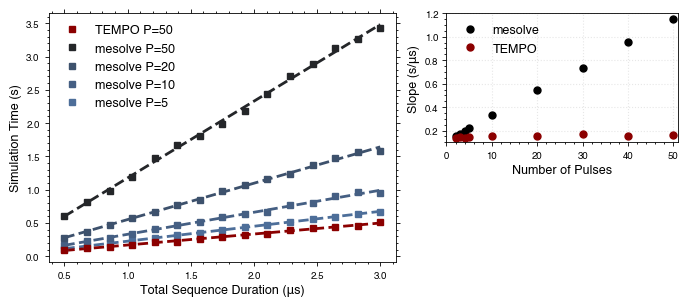

In [39]:
# ============================================================
# RIGHT PANEL: SCALING SLOPES vs NUMBER OF PULSES
# ============================================================

# Convert slope lists to numpy arrays
slopes_reg_array = np.array(slopes_reg)
slopes_serial_array = np.array(slopes_serial)

# Plot styling for right panel
kwargs_plt_right = dict(ls="", marker="o", lw=2, markersize=5)

# Plot mesolve slopes (black)
ax2.plot(
    num_pulses, slopes_reg_array,
    **kwargs_plt_right,
    color="k",
    label="mesolve"
)

# Plot TEMPO slopes (dark red)
ax2.plot(
    num_pulses, slopes_serial_array,
    **kwargs_plt_right,
    color=colors_serial[-1],  # Darkest red from palette
    label="TEMPO"
)

# ===== RIGHT PANEL FORMATTING =====
ax2.set_xlabel('Number of Pulses', **font1)
ax2.set_ylabel('Slope (s/μs)', **font1)

ax2.legend(prop=font, framealpha=0, loc='upper left')

# Set axis limits
xrange2 = (0, num_pulses.max() + 1)
ax2.set_xlim(xrange2)
yrange2_min = math.floor(min(slopes_reg_array.min(), slopes_serial_array.min()) * 10) / 10
yrange2_max = math.ceil(max(slopes_reg_array.max(), slopes_serial_array.max()) * 10) / 10
ax2.set_ylim((yrange2_min, yrange2_max))

# Customize tick appearance
ax2.tick_params(axis='both', which='major', pad=3)
ax2.tick_params(axis='x', which='both', top=False, bottom=True)
ax2.tick_params(axis='y', which='minor', left=True)
ax2.tick_params(axis='y', which='both', right=False)

# Add grid for readability
ax2.grid(True, alpha=0.3, linestyle=':')

# Turn off third panel (layout spacer)
ax3.axis("off")

print("Right panel completed: Slopes vs pulse count")
print(f"\nFigure complete!")

# ===== DISPLAY FIGURE =====
plt.show()